# MMN12

submitted by: Roi Argaman | 312496441

date: 2024-06-15


## Question 1 - implementing 
```python
my_sampler(size, dist, requires_grad=False)
```


In [1]:
import torch

def dist_format_check(dist: any) -> torch.Tensor:
    """
    Ensure that `dist` is a 1D tensor of probabilities.
    Accepts: 1D torch.Tensor, list, or tuple.
    """
    if isinstance(dist, torch.Tensor):
        if dist.dim() != 1:
            raise ValueError("dist must be a 1D tensor of probabilities.")
        return dist.to(dtype=torch.float32)
    
    if isinstance(dist, (list, tuple)):
        dist_tensor = torch.tensor(dist, dtype=torch.float32)
        if dist_tensor.dim() != 1:
            raise ValueError("dist must be a 1D tensor of probabilities.")
        return dist_tensor
    
    raise TypeError("dist must be a 1D tensor or a list/tuple of probabilities.")


def dist_values_check(dist: torch.Tensor) -> bool:
    """
    Check that all probabilities are positive and sum to 1.
    """
    if torch.any(dist <= 0):
        raise ValueError("All probabilities must be positive.")
    
    sum_vals = dist.sum()
    one = torch.tensor(1.0, dtype=dist.dtype, device=dist.device)
    
    if not torch.isclose(sum_vals, one):
        raise ValueError(f"Distribution values must sum to 1 (got {sum_vals.item():.6f}).")
    
    return True


def test_dist(dist: any) -> torch.Tensor:
    """
    Format and validate the distribution.
    """
    dist_tensor = dist_format_check(dist)
    dist_values_check(dist_tensor)
    return dist_tensor


 Building the constractore

In [2]:
def my_sampler(size, dist, requires_grad: bool = False) -> torch.Tensor:
    """
    Sample from a discrete distribution defined by `dist`.
    - size: int or tuple, the desired output shape.
    - dist: 1D tensor/list/tuple of probabilities, dist[i] = P(I = i).
    - requires_grad: if True, return a tensor tracked by autograd,
      but the sampling computation itself is not tracked.
    """
    # Validate distribution
    dist_tensor = test_dist(dist)
    n = dist_tensor.numel()
    
    # Cumulative distribution
    cum_dist = torch.cumsum(dist_tensor, dim=0)  # shape: (n,)
    
    with torch.no_grad():
        # Uniform samples in [0, 1), same shape as the output
        U = torch.rand(size)
        
        # Initialize result with the last category (index n-1)
        res = torch.full_like(U, fill_value=float(n - 1))
        
        # Single allowed loop: i = 0, ..., n-2
        for i in range(n - 1):
            if i == 0:
                mask = U < cum_dist[0]
            else:
                mask = (U >= cum_dist[i - 1]) & (U < cum_dist[i])
            res[mask] = float(i)
    
    # Autograd should only track further operations, not the sampling itself
    if requires_grad:
        res.requires_grad_(True)
    
    return res

Plotting histograms:   0%|          | 0/4 [00:00<?, ?it/s]

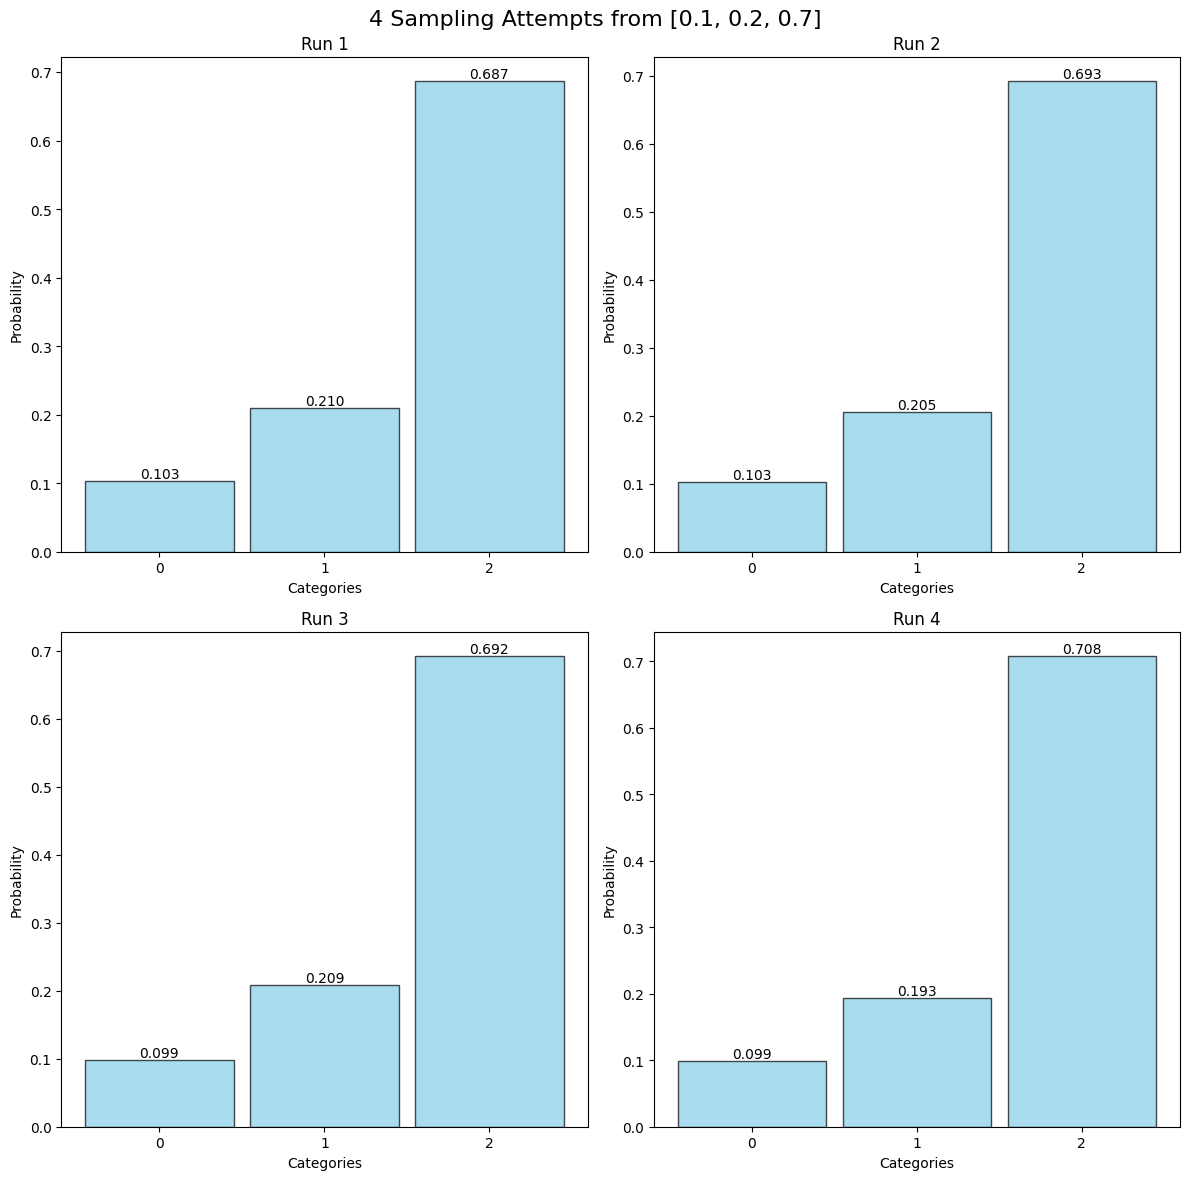

In [3]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Generate 4 independent sampling runs
arr = [my_sampler(10000, [0.1, 0.2, 0.7]) for _ in range(4)]

# Bin edges so each category has width exactly 1
bin_edges = [-0.5, 0.5, 1.5, 2.5]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for i, ax in enumerate(tqdm(axes.flat, desc="Plotting histograms")):
    data = arr[i].numpy()
    
    # Plot histogram with density=True and bin width 1 → heights = probabilities
    counts, _, patches = ax.hist(
        data,
        bins=bin_edges,
        density=True,
        alpha=0.7,
        rwidth=0.9,
        color='skyblue',
        edgecolor='black'
    )
    
    # Add labels on top of bars
    ax.bar_label(ax.containers[0], fmt='%.3f')
    
    ax.set_xticks([0, 1, 2])
    ax.set_xlabel("Categories")
    ax.set_ylabel("Probability")
    ax.set_title(f"Run {i+1}")

fig.suptitle("4 Sampling Attempts from [0.1, 0.2, 0.7]", fontsize=16)
plt.tight_layout()
plt.show()


#### **Explanation**

In this exercise, we sampled values from the discrete distribution **[0.1, 0.2, 0.7]**, where each probability corresponds to choosing categories **0**, **1**, and **2**, respectively.
We repeated the sampling procedure **four times**, drawing **10,000 samples** per run.

---

#### **What we did**

* Used the custom **`my_sampler`** function to generate 10,000 categorical samples per experiment.
* Displayed the four results in a **2×2 grid** to visually compare the stability and randomness across repeated runs.
* Used bin edges **[-0.5, 0.5, 1.5, 2.5]** so that each histogram bin covers exactly one category (width = 1).
  This makes the histogram bar heights equal to the **empirical probabilities**.

---

#### **Why the graph is built this way**

* The **2×2 grid** allows an easy side-by-side comparison of multiple independent runs.
* Setting bin width to **1** ensures that `density=True` makes the bar height equal the probability for each category, rather than a density scaled by bin width.
* This produces histograms where the bar heights should be close to **0.1**, **0.2**, and **0.7**, matching the target distribution.

---

#### **Why we see ~10%, ~20%, ~70% across four runs**

* Each of the four runs samples independently from the same distribution.
* With **10,000 samples**, the **law of large numbers** ensures that the observed frequencies converge to the true probabilities:

  * ~10% of samples fall in category **0**
  * ~20% fall in category **1**
  * ~70% fall in category **2**
* Although random variation exists, the large number of samples keeps the results consistently close to the expected proportions.


### Testing function

In [4]:
def run(name, fn):
    try:
        fn()
        print(f"[OK]   {name}")
    except Exception as e:
        print(f"[FAIL] {name} - {type(e).__name__}: {e}")


In [5]:
def test_basic_sampling():
    x = my_sampler(10, [0.5, 0.5])
    assert isinstance(x, torch.Tensor)
    assert x.shape == (10,)
    vals = torch.unique(x)
    assert torch.all(vals >= 0) and torch.all(vals <= 1)


def test_shape_tuple_size():
    x = my_sampler((2,5), [0.3,0.7])
    assert x.shape == (2,5)


def test_requires_grad_false():
    x = my_sampler(10, [0.5, 0.5], requires_grad=False)
    assert x.requires_grad is False


def test_requires_grad_true():
    x = my_sampler(10, [0.5, 0.5], requires_grad=True)
    assert x.requires_grad is True


def test_single_category():
    x = my_sampler(100,[1.0])
    assert x.shape == (100,)
    assert torch.all(x == 0.0)


def test_values_are_indices():
    x = my_sampler(1000,[0.1,0.2,0.7])
    vals = torch.unique(x)
    assert torch.all(vals >= 0) and torch.all(vals < 3)


def test_empirical_probabilities():
    s = my_sampler(10000,[0.1,0.2,0.7]).to(torch.long)
    counts = torch.bincount(s, minlength=3).float() / 10000
    max_err = torch.max(torch.abs(counts - torch.tensor([0.1,0.2,0.7]))).item()
    assert max_err < 0.03


def test_invalid_sum():
    try:
        my_sampler(10, [0.5, 0.6])
        assert False, "Expected ValueError"
    except ValueError:
        pass


def test_negative_value():
    try:
        my_sampler(10, [0.5, -0.5, 1.0])
        assert False, "Expected ValueError"
    except ValueError:
        pass


def test_zero_value():
    try:
        my_sampler(10, [0.0, 1.0])
        assert False, "Expected ValueError"
    except ValueError:
        pass


def test_non_1d_tensor():
    try:
        my_sampler(10, torch.tensor([[0.5, 0.5]]))
        assert False, "Expected ValueError"
    except ValueError:
        pass


def test_wrong_type():
    try:
        my_sampler(10, "bad")
        assert False, "Expected TypeError"
    except TypeError:
        pass


In [6]:
import time
tests = [
    ("basic_sampling",         test_basic_sampling),
    ("shape_tuple_size",       test_shape_tuple_size),
    ("requires_grad_false",    test_requires_grad_false),
    ("requires_grad_true",     test_requires_grad_true),
    ("single_category",        test_single_category),
    ("values_are_indices",     test_values_are_indices),
    ("empirical_probabilities",test_empirical_probabilities),
    ("invalid_sum",            test_invalid_sum),
    ("negative_value",         test_negative_value),
    ("zero_value",             test_zero_value),
    ("non_1d_tensor",          test_non_1d_tensor),
    ("wrong_type",             test_wrong_type),
]

for name, fn in tqdm(tests, desc="Running tests"):
    run(name, fn)


Running tests:   0%|          | 0/12 [00:00<?, ?it/s]

[OK]   basic_sampling
[OK]   shape_tuple_size
[OK]   requires_grad_false
[OK]   requires_grad_true
[OK]   single_category
[OK]   values_are_indices
[OK]   empirical_probabilities
[OK]   invalid_sum
[OK]   negative_value
[OK]   zero_value
[OK]   non_1d_tensor
[OK]   wrong_type


## Question 2 - implementing MyScalar


In [50]:
import math  # for exp, etc.

# global dict for gradients (key: MyScalar object, value: d(output)/d(that object))
GRAD_DICT = {}

"""
value – numeric value

grad_local – local derivative w.r.t. its parent (∂this / ∂parent)

parent – the MyScalar this one was computed from (or None)
"""

class MyScalar:
    def __init__(self, value, parent=None, grad_local=1.0, name=None):
        self.value = float(value)
        self.parent = parent        # another MyScalar, or None for leaf
        self.grad_local = float(grad_local)  # local derivative: d(this)/d(parent)

    
    def __repr__(self):
        return f"MyScalar(value={self.value}, grad_local={self.grad_local})"

tests = [] # List to save all tests that will be defined per cell and run at the end

In [51]:
import math

def check(cond, msg=""):
    """Use instead of assert inside lambdas."""
    if not cond:
        raise AssertionError(msg or "check() failed")

def assert_close(a, b, tol=1e-6):
    if abs(a - b) > tol:
        raise AssertionError(f"Expected {b}, got {a}")
    return True

def run(name, fn):
    try:
        fn()
        print(f"[OK]   {name}")
    except Exception as e:
        print(f"[FAIL] {name} - {type(e).__name__}: {e}")

In [ ]:
# 1. Basic MyScalar
tests.append(("scalar_init_basic",
    lambda: (assert_close(MyScalar(2.5).value, 2.5),check(MyScalar(3.0).parent is None),assert_close(MyScalar(4.0).grad_local, 1.0))))


In [ ]:
def sin(x: MyScalar) -> MyScalar:
    """
    y = sin(x)
    parent = x
    grad_local = dy/dx = cos(x)
    """
    t = torch.tensor(x.value, dtype=torch.float32)

    value = torch.sin(t).item()      # float
    grad_local = torch.cos(t).item() # float

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.sin = sin # Adding sin as a method of MyScalar

# 2. Adding sin test to the tests list 
tests.append(("sin_value_and_grad_local",
    lambda: (lambda x=0.7: (assert_close(sin(MyScalar(x)).value, torch.sin(torch.tensor(x)).item()),
            assert_close(sin(MyScalar(x)).grad_local, torch.cos(torch.tensor(x)).item())
        ))()
))

In [52]:
def cos(x: MyScalar) -> MyScalar:
    """
    y = cos(x)
    parent = x
    grad_local = dy/dx = -sin(x)
    """
    t = torch.tensor(x.value, dtype=torch.float32)

    value = torch.cos(t).item()
    grad_local = (-torch.sin(t)).item()

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.cos = cos # Adding cos as a method of MyScalar

# 3. Adding cos test to the tests list
tests.append(("cos_value_and_grad_local",
    lambda: (lambda x=1.2: (assert_close(cos(MyScalar(x)).value, torch.cos(torch.tensor(x)).item()),
            assert_close(cos(MyScalar(x)).grad_local, (-torch.sin(torch.tensor(x))).item())
        ))()))

In [ ]:
def ln(x: MyScalar) -> MyScalar:
    """
    y = ln(x)
    parent = x
    grad_local = dy/dx = 1/x
    """
    t = torch.tensor(x.value, dtype=torch.float32)

    value = torch.log(t).item()
    grad_local = (1.0 / t).item()

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.ln = ln # Adding ln as a method of MyScalar

# 4. Adding ln test to the tests list
tests.append(("ln_value_and_grad_local",
    lambda: (lambda x=2.3: (assert_close(ln(MyScalar(x)).value, torch.log(torch.tensor(x)).item()),
            assert_close(ln(MyScalar(x)).grad_local, (1.0/torch.tensor(x)).item())
        ))()))

In [ ]:
def exp(x: MyScalar) -> MyScalar:
    """
    y = exp(x) = e^x
    parent = x
    grad_local = dy/dx = e^x
    """
    t = torch.tensor(x.value, dtype=torch.float32)

    value_t = torch.exp(t)          # tensor
    value = value_t.item()          # float
    grad_local = value_t.item()     # derivative of e^x is e^x

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.exp = exp # Adding exp as a method of MyScalar

# 5. Adding exp test to the tests list
tests.append(("exp_value_and_grad_local",
        lambda: (lambda x=0.9: (assert_close(exp(MyScalar(x)).value, torch.exp(torch.tensor(x)).item()),
            assert_close(exp(MyScalar(x)).grad_local, torch.exp(torch.tensor(x)).item())
        ))()))

In [ ]:
def power(x: MyScalar, n: float) -> MyScalar:
    """
    y = x^n   (n is a scalar constant)
    parent = x
    grad_local = dy/dx = n * x^(n-1)
    """
    t = torch.tensor(x.value, dtype=torch.float32)

    value = (t ** n).item()
    grad_local = (n * (t ** (n - 1))).item()

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.power =  power # Adding power as a method of MyScalar

# 6. Adding power test to the tests list
tests.append(("power_value_and_grad_local",
    lambda: (lambda x=1.5, n=3: (assert_close(power(MyScalar(x), n).value, x**n),assert_close(power(MyScalar(x), n).grad_local, n * x**(n-1))))()))

In [ ]:
def gradient_get(output: MyScalar):
    """
    Compute d(output)/d(x) for all x in the chain by backpropagation.

    Uses global GRAD_DICT:
      key   = MyScalar object
      value = float with d(output)/d(that object)
    """
    global GRAD_DICT
    GRAD_DICT = {}  # reset

    def _backprop(node: MyScalar, grad_to_node: float):
        """
        node: current MyScalar
        grad_to_node: d(output)/d(node) as float
        """
        global GRAD_DICT

        # accumulate gradient for this node
        if node in GRAD_DICT:
            GRAD_DICT[node] += grad_to_node
        else:
            GRAD_DICT[node] = grad_to_node

        # propagate to parent if it exists
        if node.parent is not None:
            # chain rule:
            # d(output)/d(parent) = d(output)/d(node) * d(node)/d(parent)
            grad_to_parent = grad_to_node * node.grad_local
            _backprop(node.parent, grad_to_parent)

    # seed: d(output)/d(output) = 1
    _backprop(output, 1.0)

    return GRAD_DICT

# --- Add tests for gradient_get ---

# 7. Adding gradient_get on leaf test to the tests list
tests.append(("gradient_leaf",
    lambda: (lambda a=MyScalar(3.3), g=gradient_get(MyScalar(3.3)): (
            assert_close(g[list(g.keys())[0]], 1.0),check(len(g) == 1)))()))

# 8. Adding chain rule: a → b=a² → c=exp(b) test to the tests list
tests.append(("gradient_chain",
    lambda: (lambda a_val=2.0, a=MyScalar(2.0): (lambda b=power(a, 2), c=exp(b), g=gradient_get(c): (
                assert_close(g[c], 1.0),
                assert_close(g[b], math.exp(b.value)),
                assert_close(g[a], math.exp(b.value) * 2 * a_val)
            ))())))

# 9. Adding reassignment test to the tests list
tests.append(("reassignment_chain",
    lambda: (lambda x=2.0: (lambda a=MyScalar(x): (lambda a1=power(a,2), a2=exp(a1), g=gradient_get(a2): (
                    assert_close(g[a], math.exp(x**2) * 2*x)))())())))

#### Run Unit Tests for MyScalar and its methods

In [46]:
for name, fn in tqdm(tests, desc="Running tests"):
    run(name, fn)

Running tests:   0%|          | 0/9 [00:00<?, ?it/s]

[OK]   scalar_init_basic
[OK]   sin_value_and_grad_local
[OK]   cos_value_and_grad_local
[OK]   ln_value_and_grad_local
[OK]   exp_value_and_grad_local
[OK]   power_value_and_grad_local
[OK]   gradient_leaf
[OK]   gradient_chain
[OK]   reassignment_chain


#### Define the tests MyScalar to Pytorch autograd

In [56]:
from tqdm.notebook import tqdm
import torch
import math

def assert_close(a, b, tol=1e-6):
    if abs(a - b) > tol:
        raise AssertionError(f"Expected {b}, got {a} (diff={abs(a-b)})")

def run(name, fn):
    try:
        fn()
        print(f"[OK]   {name}")
    except Exception as e:
        print(f"[FAIL] {name} - {type(e).__name__}: {e}")

def compare_with_torch(name, f_my, f_torch, x_values):
    """
    name     : scenario name
    f_my     : function taking MyScalar -> MyScalar (your engine)
    f_torch  : function taking torch.Tensor -> torch.Tensor (PyTorch)
    x_values : list of float values to test
    """
    def test_fn():
        for x in x_values:
            # --- Our system ---
            a = MyScalar(x)
            y = f_my(a)               # final MyScalar
            grads = gradient_get(y)
            grad_my = grads[a]        # dy/dx according to our engine
            val_my = y.value          # function value

            # --- PyTorch system ---
            x_t = torch.tensor(x, dtype=torch.float32, requires_grad=True)
            y_t = f_torch(x_t)        # output tensor
            y_t.backward()
            grad_t = x_t.grad.item()  # dy/dx, PyTorch
            val_t = y_t.item()        # function value

            # Compare values and gradients
            assert_close(val_my, val_t)
            assert_close(grad_my, grad_t)

    run(name, test_fn)

In [42]:
scenarios = []

# 1. f(x) = sin(x)
scenarios.append((
    "f(x) = sin(x)",
    lambda a: sin(a),
    lambda x: torch.sin(x),
    [-2.0, -0.5, 0.0, 0.7, 1.3, 3.0]
))

# 2. f(x) = cos(x)
scenarios.append((
    "f(x) = cos(x)",
    lambda a: cos(a),
    lambda x: torch.cos(x),
    [-2.0, -0.5, 0.0, 0.7, 1.3, 3.0]
))

# 3. f(x) = ln(x)  (x must be > 0)
scenarios.append((
    "f(x) = ln(x)",
    lambda a: ln(a),
    lambda x: torch.log(x),
    [0.5, 0.8, 1.0, 2.0, 3.5]
))

# 4. f(x) = exp(x)
scenarios.append((
    "f(x) = exp(x)",
    lambda a: exp(a),
    lambda x: torch.exp(x),
    [-1.0, -0.3, 0.0, 0.4, 1.2]
))

# 5. f(x) = x^2
scenarios.append((
    "f(x) = x^2",
    lambda a: power(a, 2),
    lambda x: x**2,
    [-2.0, -1.0, 0.0, 1.5, 3.0]
))

# 6. f(x) = x^3
scenarios.append((
    "f(x) = x^3",
    lambda a: power(a, 3),
    lambda x: x**3,
    [-2.0, -1.0, 0.0, 1.5, 3.0]
))

# 7. f(x) = exp(x^2)
scenarios.append((
    "f(x) = exp(x^2)",
    lambda a: exp(power(a, 2)),
    lambda x: torch.exp(x**2),
    [-2.0, -1.0, -0.3, 0.3, 1.0, 2.0]
))

# 8. f(x) = sin(exp(x))
scenarios.append((
    "f(x) = sin(exp(x))",
    lambda a: sin(exp(a)),
    lambda x: torch.sin(torch.exp(x)),
    [-1.0, -0.5, 0.0, 0.5, 1.0]
))

# 9. f(x) = exp(sin(x^2))
scenarios.append((
    "f(x) = exp(sin(x^2))",
    lambda a: exp(sin(power(a, 2))),
    lambda x: torch.exp(torch.sin(x**2)),
    [-2.0, -1.0, -0.3, 0.3, 1.0, 2.0]
))


In [57]:
for item in tqdm(scenarios, desc="Comparing with PyTorch"):
    name, f_my, f_torch, xs = item
    compare_with_torch(name, f_my, f_torch, xs)


Comparing with PyTorch:   0%|          | 0/9 [00:00<?, ?it/s]

[OK]   f(x) = sin(x)
[OK]   f(x) = cos(x)
[OK]   f(x) = ln(x)
[OK]   f(x) = exp(x)
[OK]   f(x) = x^2
[OK]   f(x) = x^3
[OK]   f(x) = exp(x^2)
[OK]   f(x) = sin(exp(x))
[OK]   f(x) = exp(sin(x^2))
